# Online Retail II – Sales & Cancellation Analysis  

This notebook analyzes the **Online Retail II (UCI)** dataset, which contains over 1 million transactions from 2009 to 2011.  
The dataset reflects real-world e-commerce activity, where each row is a product in an invoice.  

The main objective is to study **order cancellations** and understand their impact on sales.  
Cancellations represent lost revenue and can highlight issues such as product quality, customer behavior, or operational inefficiencies.  

The analysis is structured into the following steps:
1. [**Data Understanding**](#1.-Data-Understanding) : Check and preparing the data, looking at data size, data type, missing values, and duplicated values 
2. [**Data Cleaning**](#2.-Data-Cleaning) : Remove duplicates, invalid prices/quantities, and irrelevant records. Separate confirmed sales from cancellations.  
3. [**Sales vs Cancelled Overview**](#3.-Sales-vs-Cancelled-Overview) : Measure total sales, cancellations, and the overall scale of financial loss.  
4. [**Cancellations by Country**](#4.-Cancellations-by-Country) : Identify which markets contribute the most to cancellations, both in value and transaction counts.  
5. [**Cancellations by Product**](#5.-Cancellations-by-Product) : Highlight products that cause the biggest financial losses or face repeated cancellation issues.  
6. [**Cancellations by Customer**](#6.-Cancellations-by-Customer) : Spot customers with high cancellation activity or unusual behavior.  
7. [**Cancellations Over Time**](#7.-Cancellations-Over-Time) : Explore seasonal patterns in sales and cancellations across the year.  
8. [**Final Insights & Recommendations**](#Final-Insights-&-Recommendations) : Summarize key findings and provide recommendations for reducing cancellations.  

This structured approach combines both data exploration and business interpretation, aiming to uncover **where and why cancellations happen** and what actions can help minimize them.  


### Environment Setup and Importing necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## 1. Data Understanding

The dataset comes from the **Online Retail II (UCI)** collection, containing e-commerce transactions between **December 2009 and December 2011**.

Each row represents a product purchased within an invoice. Key columns include:

- **Invoice** : Unique identifier for each transaction. Invoices starting with 'C' indicate cancellations.  
- **StockCode** : Product code (SKU).  
- **Description** : Product description.  
- **Quantity** : Number of units purchased. Negative values indicate returns.  
- **InvoiceDate** : Date and time when the invoice was generated.  
- **Price** : Unit price of the product.  
- **Customer ID** : Unique identifier for each customer. Some transactions have missing values here.  
- **Country** : Country where the customer resides.

Import the dataset using from csv to pandas

In [2]:
df = pd.read_csv('online_retail_II.csv')

### Checking and Preparing the Data

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.duplicated().sum()

np.int64(34335)

In [6]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

## 2. Data Cleaning  

Real-world transaction data often includes errors, duplicates, and non-sales records that can distort analysis.  
To make sure our findings are accurate, we applied the following cleaning steps:

1. **Remove duplicates**  
   - Some transactions were recorded multiple times.  
   - Keeping duplicates would inflate sales and return counts.  

2. **Separate valid sales and cancellations**  
   - Invoices starting with **"C"** indicate cancellations.  
   - We split the dataset into two parts:  
     - `valid_sales` → all normal purchases  
     - `cancelled` → all cancelled transactions  

3. **Remove invalid quantities and prices**  
   - Sales with **negative quantities** or **zero/negative prices** are excluded.  

4. **Remove irrelevant stock codes**  
   - Some rows contain entries like *TEST, DISCOUNT, CARRIAGE, POSTAGE, etc.*  
   - These do not represent actual products and are removed from both sales and returns.  

After cleaning, we now have two datasets:  
- **Valid Sales** represents genuine purchases.  
- **Cancelled** represents cancelled/returned transactions.  

These cleaned datasets will be the foundation for analyzing how much value is being generated and how much is being lost.


In [7]:
df.drop_duplicates(inplace=True)

cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
valid_sales = df[~df['Invoice'].astype(str).str.startswith('C')]


valid_sales = valid_sales[(valid_sales['Quantity'] > 0) & (valid_sales['Price'] > 0)]

remove_keywords = [
    'TEST', 'ADJUST', 'DISCOUNT', 'CARRIAGE', 'PADS',
    'GIFT', 'MANUAL', 'POSTAGE', 'BANK CHARGES', 
    'AMAZONFEE', 'SAMPLE', 'CRUK'
]

pattern = '|'.join(remove_keywords)
valid_sales = valid_sales[~valid_sales['Description'].str.contains(pattern, case=False, na=False)]
valid_sales = valid_sales[~valid_sales['StockCode'].str.upper().str.contains(pattern, na=False)]
cancelled = cancelled[~cancelled['Description'].str.contains(pattern, case=False, na=False)]
cancelled = cancelled[~cancelled['StockCode'].str.upper().str.contains(pattern, na=False)]


valid_sales = valid_sales.reset_index(drop=True)
cancelled = cancelled.reset_index(drop=True)

print('Valid sales:', valid_sales.shape)
print('Cancelled:', cancelled.shape)

Valid sales: (993093, 9)
Cancelled: (17786, 9)


## 3. Sales vs Cancelled Overview  

Before diving into detailed analysis, it’s important to get a **big-picture view** of the data.  
This helps us understand the overall size of the business activity and the impact of cancellations.  

We calculate:  
- **Total Sales Revenue (£)** : total value from valid transactions.  
- **Total Value Cancelled (£)** : value lost from cancellations.  
- **Number of Sales Transactions** : count of purchase invoices.  
- **Number of Cancelled Transactions** : count of cancelled invoices.  
- **Number of Unique Products** : how many different products were sold.  
- **Number of Unique Customers** : how many distinct customers made purchases.  
- **Cancellation Rate (transactions %)** : share of total transactions that were cancelled.  
- **Percentage of Revenue Lost (%)** : share of total value lost to cancellations.  

This overview gives us a clear starting point: how much money is being made,  
and how much is being lost due to cancellations.


In [8]:
# Total revenue
total_sales_revenue = valid_sales['Revenue'].sum()
total_cancelled_value = cancelled['Revenue'].sum()

# Number of transactions
num_sales = valid_sales['Invoice'].nunique()
num_cancel = cancelled['Invoice'].nunique()

# Number of unique products
num_products = valid_sales['StockCode'].nunique()

# Number of unique customers
num_customers = valid_sales['Customer ID'].nunique()

# Percentages
cancel_rate_tx = num_cancel / (num_sales + num_cancel) * 100
cancel_rate_val = total_cancelled_value / (total_sales_revenue + total_cancelled_value) * 100

print('Total Sales Revenue: £{:,.2f}'.format(total_sales_revenue))
print('Total Value Cancelled: £{:,.2f}'.format(total_cancelled_value))
print('Number of Sales Transactions:', num_sales)
print('Number of Cancelled Transactions:', num_cancel)
print('Number of Unique Products:', num_products)
print('Number of Unique Customers:', num_customers)
print('Cancellation Rate (transactions): {:.2f}%'.format(cancel_rate_tx))
print('Percentage of Revenue Lost: {:.2f}%'.format(cancel_rate_val))


Total Sales Revenue: £19,460,497.13
Total Value Cancelled: £-712,889.34
Number of Sales Transactions: 39480
Number of Cancelled Transactions: 7383
Number of Unique Products: 4825
Number of Unique Customers: 5852
Cancellation Rate (transactions): 15.75%
Percentage of Revenue Lost: -3.80%


## 4. Cancellations by Country  

To understand where cancellations are happening, we break down sales and cancellations by country.  

For each country, we calculate:  
- **Total Sales Revenue (£)** – confirmed purchases.  
- **Total Cancelled Value (£)** – financial value lost from cancellations.  
- **Total Cancelled Transactions** – number of transactions cancelled. 

This gives us both a financial and operational perspective:  
- Countries with high **cancelled value** represent the largest monetary loss.  
- Countries with high **cancelled transactions** may point to market-specific issues, such as logistics, product demand mismatch, or payment problems.  


In [16]:
country_sales = valid_sales.groupby('Country')['Revenue'].sum()
country_cancel = cancelled.groupby('Country')['Revenue'].sum()
country_tx_sales = valid_sales.groupby('Country')['Invoice'].nunique()
country_tx_cancel = cancelled.groupby('Country')['Invoice'].nunique()

country_summary = pd.DataFrame({
    'SalesRevenue': country_sales,
    'CancelledValue': country_cancel,
    'SalesTransactions': country_tx_sales,
    'CancelledTransactions': country_tx_cancel
}).fillna(0)

country_summary = country_summary.sort_values(by='CancelledValue').head(10)

country_summary


,SalesRevenue,CancelledValue,SalesTransactions,CancelledTransactions
Country,,,,
United Kingdom,16655182.16,-629072.58,36150,6572.0
EIRE,613821.21,-20297.55,580,146.0
France,306276.99,-17471.89,597,111.0
Spain,96652.35,-12955.19,144,24.0
Germany,378356.03,-8701.24,753,282.0
Denmark,66073.65,-4067.10,42,8.0
Netherlands,545566.42,-3540.58,216,11.0
Japan,41687.56,-3262.69,33,20.0
Channel Islands,43544.43,-2158.22,54,21.0


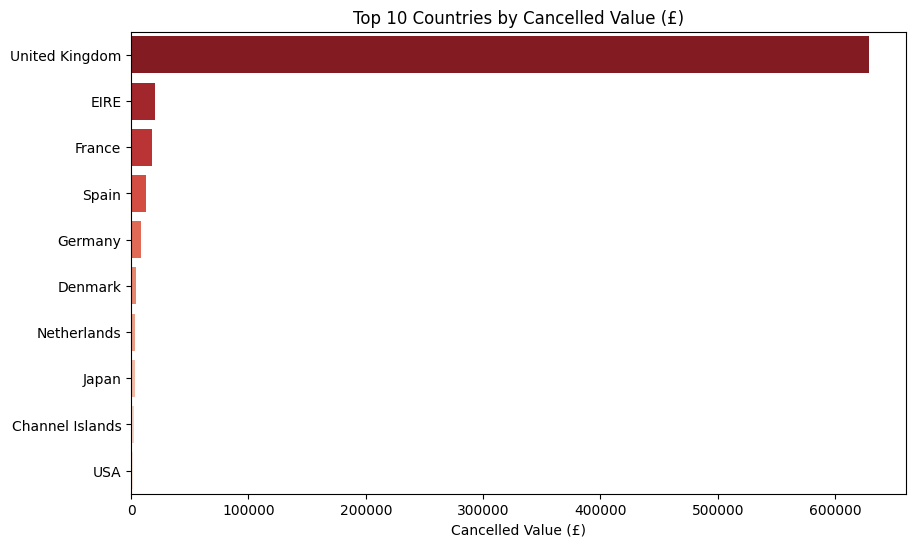

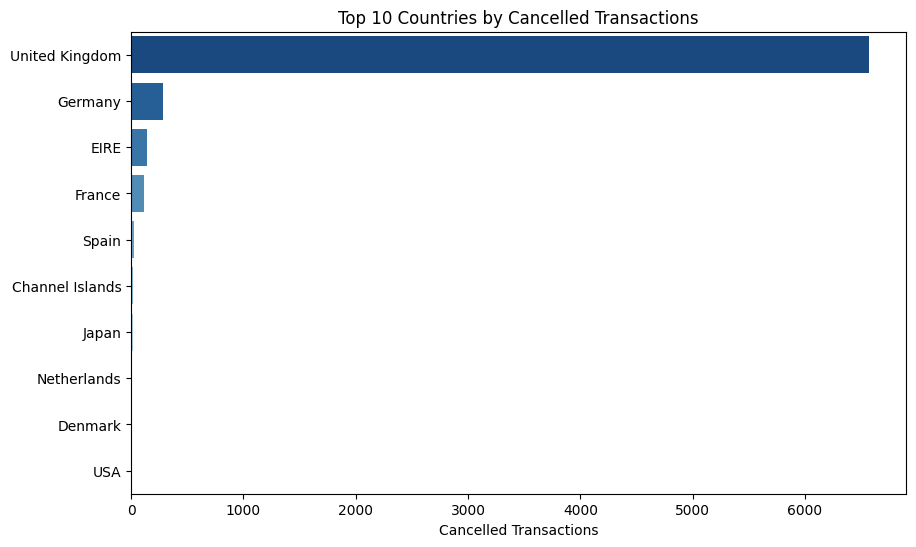

In [18]:
top_cancel_value = (
    country_summary.assign(CancelledValueAbs=country_summary['CancelledValue'].abs())
    .sort_values(by='CancelledValueAbs', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_cancel_value,
    x='CancelledValueAbs', y='Country',
    hue='Country', legend=False,
    palette='Reds_r'
)
plt.title('Top 10 Countries by Cancelled Value (£)')
plt.xlabel('Cancelled Value (£)')
plt.ylabel('')
plt.show()


top_cancel_rate = (
    country_summary.sort_values(by='CancelledTransactions', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_cancel_rate,
    x='CancelledTransactions', y='Country',
    hue='Country', legend=False,
    palette='Blues_r'
)
plt.title('Top 10 Countries by Cancelled Transactions')
plt.xlabel('Cancelled Transactions')
plt.ylabel('')
plt.show()


From the country analysis,  
- The **UK** leads in both sales (£16.6M) and cancellations (£629K, 6,572 orders). But since it also has the largest number of transactions overall, its high cancellations are expected.  
- **Germany** stands out with 282 cancelled orders, the most outside the UK.  
- **EIRE** and **France** also show noticeable cancellations (146 and 111).  
- Smaller markets like **Spain**, **Japan**, and **Channel Islands** contribute less to sales but still face cancellations.  

Overall, while the UK loses the most in value, its scale explains much of it. The more concerning cases are countries with **smaller sales but relatively high cancellation counts**, such as Germany.  


## 5. Cancellations by Product  

To identify which products are most affected, we break down sales and cancellations at the product level.  

For each product, we calculate:  
- **Total Sales Revenue (£)** – confirmed purchases.  
- **Total Cancelled Value (£)** – financial value lost from cancellations.  
- **Total Cancelled Transactions** – number of orders cancelled for that product.  

This helps highlight both financial impact and product-specific risks:  
- Products with high **cancelled value** cause the largest monetary losses.  
- Products with many **cancelled transactions** may indicate recurring operational or demand issues, even if the value lost is smaller.  


In [19]:
product_sales = valid_sales.groupby('Description')['Revenue'].sum()
product_cancel = cancelled.groupby('Description')['Revenue'].sum()
product_tx_sales = valid_sales.groupby('Description')['Invoice'].nunique()
product_tx_cancel = cancelled.groupby('Description')['Invoice'].nunique()

product_summary = pd.DataFrame({
    'SalesRevenue': product_sales,
    'CancelledValue': product_cancel,
    'SalesTransactions': product_tx_sales,
    'CancelledTransactions': product_tx_cancel
}).fillna(0)

product_summary = product_summary.sort_values(by='CancelledValue').head(10)

product_summary


,SalesRevenue,CancelledValue,SalesTransactions,CancelledTransactions
Description,,,,
"PAPER CRAFT , LITTLE BIRDIE",168469.60,-168469.60,1.0,1.0
MEDIUM CERAMIC TOP STORAGE JAR,81700.92,-77479.64,247.0,10.0
REGENCY CAKESTAND 3 TIER,330590.32,-16545.30,3918.0,341.0
WHITE HANGING HEART T-LIGHT HOLDER,260990.22,-9387.10,5455.0,134.0
COLOUR GLASS. STAR T-LIGHT HOLDER,41099.79,-6966.66,757.0,60.0
FAIRY CAKE FLANNEL ASSORTED COLOUR,25407.27,-6614.37,613.0,4.0
WHITE CHERRY LIGHTS,5850.06,-6331.30,106.0,119.0
SET/4 WHITE RETRO STORAGE CUBES,43844.96,-5187.65,328.0,20.0
PANTRY CHOPPING BOARD,5868.50,-4803.06,57.0,6.0


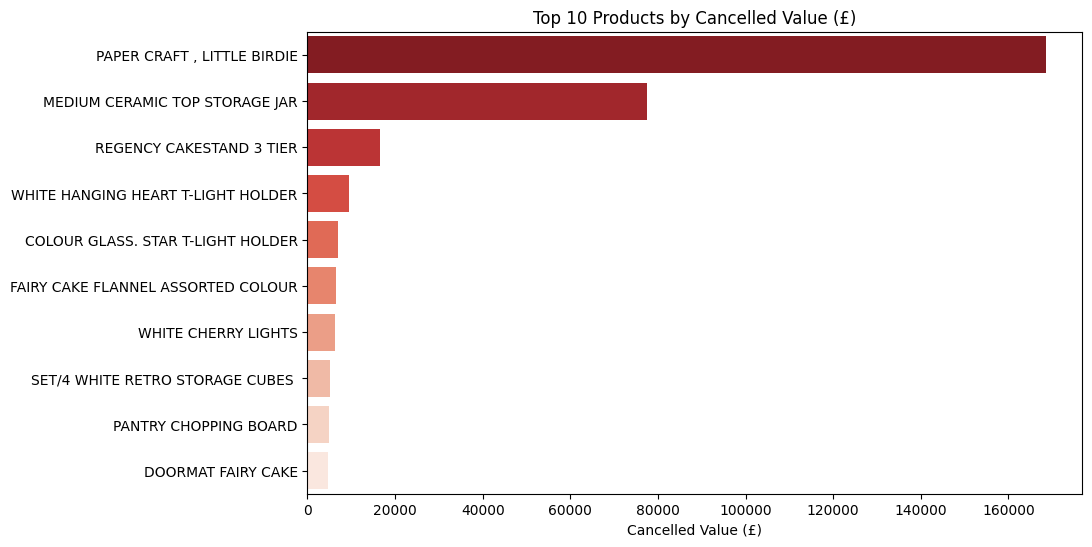

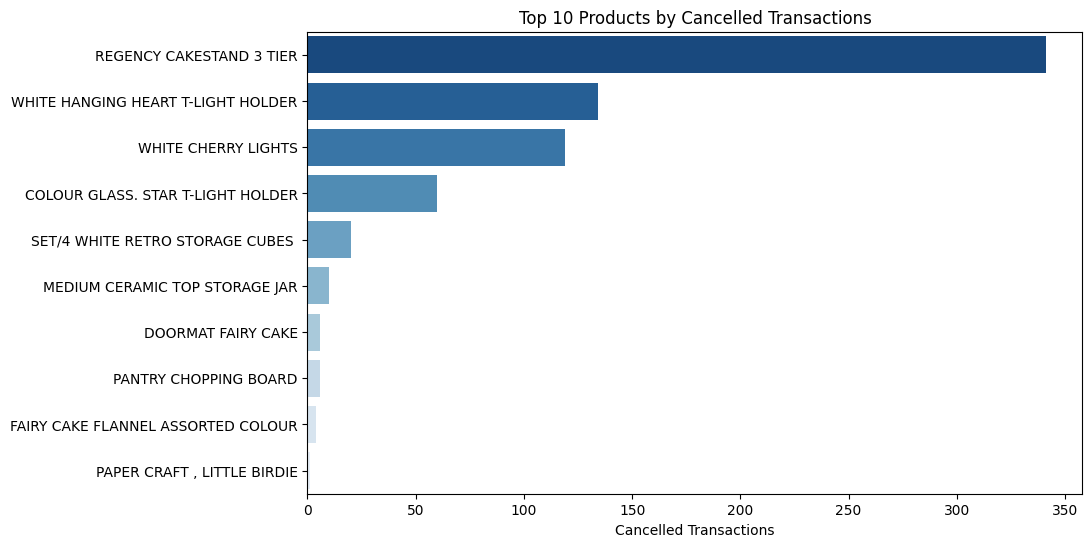

In [20]:
top_cancel_value = (
    product_summary.assign(CancelledValueAbs=product_summary['CancelledValue'].abs())
    .sort_values(by='CancelledValueAbs', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_cancel_value,
    x='CancelledValueAbs', y='Description',
    hue='Description', legend=False,
    palette='Reds_r'
)
plt.title('Top 10 Products by Cancelled Value (£)')
plt.xlabel('Cancelled Value (£)')
plt.ylabel('')
plt.show()


top_cancel_rate = (
    product_summary.sort_values(by='CancelledTransactions', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_cancel_rate,
    x='CancelledTransactions', y='Description',
    hue='Description', legend=False,
    palette='Blues_r'
)
plt.title('Top 10 Products by Cancelled Transactions')
plt.xlabel('Cancelled Transactions')
plt.ylabel('')
plt.show()


From the product analysis,  
- **PAPER CRAFT, LITTLE BIRDIE** stands out as a complete loss: £168K in sales cancelled in a single order.  
- **MEDIUM CERAMIC TOP STORAGE JAR** also shows very high cancellations (£77K), despite having only 10 cancelled orders.  
- **REGENCY CAKESTAND 3 TIER** has the highest number of cancelled orders (341), even though its cancellation value (£16K) is lower than the top two.  
- **WHITE HANGING HEART T-LIGHT HOLDER** and **COLOUR GLASS. STAR T-LIGHT HOLDER** also see significant cancellation activity (£9K and £7K).  
- **WHITE CHERRY LIGHTS** is unusual: small sales (£5.8K) but a very high number of cancelled orders (119), nearly matching its total sales volume.  

In short, some products lose the most money (like *PAPER CRAFT* and *CERAMIC JAR*), while others face heavier risks from **frequent cancellations** (like *CAKESTAND* and *CHERRY LIGHTS*).  


## 6. Cancellations by Customer  

To understand the role of customers in cancellations, we look at both their sales and their cancelled orders.  

For each customer, we calculate:  
- **Total Sales Revenue (£)** – value of confirmed purchases.  
- **Total Cancelled Value (£)** – value lost from cancellations.  
- **Total Cancelled Transactions** – number of transactions cancelled.  

This highlights customers who bring the most value, and also those who cause the biggest losses or cancel most often.  


In [23]:
customer_sales = valid_sales.groupby('Customer ID')['Revenue'].sum()
customer_cancel = cancelled.groupby('Customer ID')['Revenue'].sum()
customer_tx_sales = valid_sales.groupby('Customer ID')['Invoice'].nunique()
customer_tx_cancel = cancelled.groupby('Customer ID')['Invoice'].nunique()

customer_summary = pd.DataFrame({
    'SalesRevenue': customer_sales,
    'CancelledValue': customer_cancel,
    'SalesTransactions': customer_tx_sales,
    'CancelledTransactions': customer_tx_cancel
}).fillna(0)

customer_summary = customer_summary.sort_values(by='CancelledValue').head(10)

customer_summary


,SalesRevenue,CancelledValue,SalesTransactions,CancelledTransactions
Customer ID,,,,
16446.0,168472.50,-168469.60,2.0,1.0
12346.0,77352.96,-77183.60,3.0,1.0
15749.0,44534.30,-22998.40,3.0,1.0
12931.0,92347.34,-20800.37,57.0,11.0
14911.0,269075.11,-13730.36,373.0,93.0
14277.0,16598.06,-12642.14,8.0,5.0
16029.0,105860.67,-12554.16,105.0,6.0
12454.0,16459.78,-12360.82,4.0,3.0
17450.0,244784.25,-11140.34,51.0,4.0


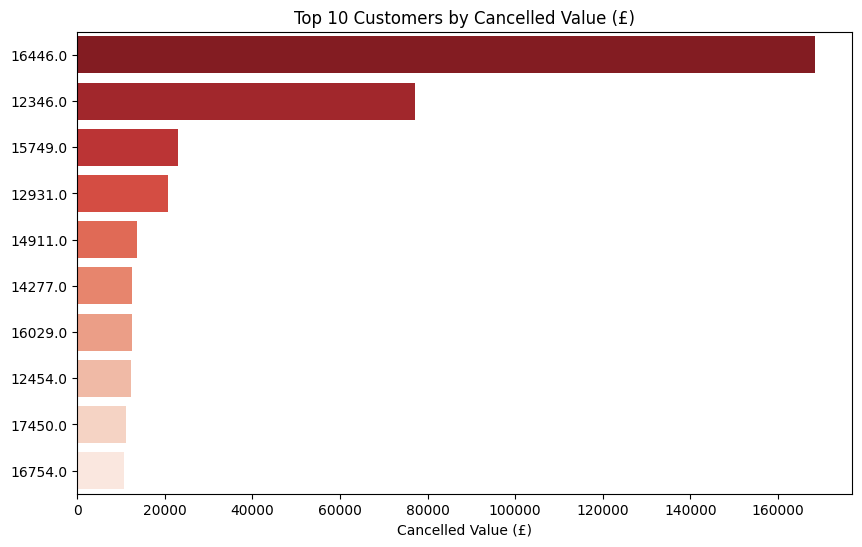

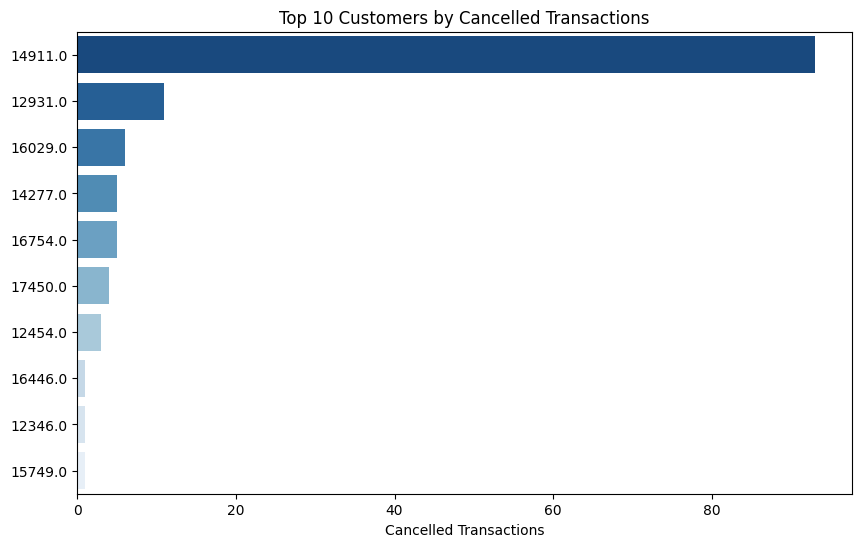

In [27]:
top_cancel_value = (
    customer_summary.assign(CancelledValueAbs=customer_summary['CancelledValue'].abs())
    .sort_values(by='CancelledValueAbs', ascending=False)
    .head(10)
    .reset_index()
)
top_cancel_value['Customer ID'] = top_cancel_value['Customer ID'].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_cancel_value,
    x='CancelledValueAbs', y='Customer ID',
    hue='Customer ID', legend=False,
    palette='Reds_r'
)
plt.title('Top 10 Customers by Cancelled Value (£)')
plt.xlabel('Cancelled Value (£)')
plt.ylabel('')
plt.show()


top_cancel_rate = (
    customer_summary.sort_values(by='CancelledTransactions', ascending=False)
    .head(10)
    .reset_index()
)
top_cancel_rate['Customer ID'] = top_cancel_rate['Customer ID'].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_cancel_rate,
    x='CancelledTransactions', y='Customer ID',
    hue='Customer ID', legend=False,
    palette='Blues_r'
)
plt.title('Top 10 Customers by Cancelled Transactions')
plt.xlabel('Cancelled Transactions')
plt.ylabel('')
plt.show()


From the customer analysis, we can see:  
- Some customers, like **ID 16446** and **12346**, cancelled items worth nearly as much as they bought, leading to large sales losses.  
- Customers with more activity, such as **14911** (93 cancellations) and **12931** (11 cancellations), show repeated issues with orders.  
- On the other hand, a few high-spending customers like **17450** still had cancellations, but these were small compared to their overall purchases.  

In short, cancellations are not only about sales value but also about customer behavior, with some customers repeatedly cancelling orders more than others.  


## 7. Cancellations Over Time  

To see how cancellations change over time, we group sales and cancellations by month.  
This shows whether cancellations are stable, growing, or seasonal.  

We calculate:  
- **Monthly Sales Revenue (£)** – confirmed purchases.  
- **Monthly Cancelled Value (£)** – value lost due to cancellations.  
- **Monthly Cancelled Transactions** – number of cancelled orders.  

This helps us spot long-term patterns, such as seasonal spikes or months with unusual cancellation behavior.  


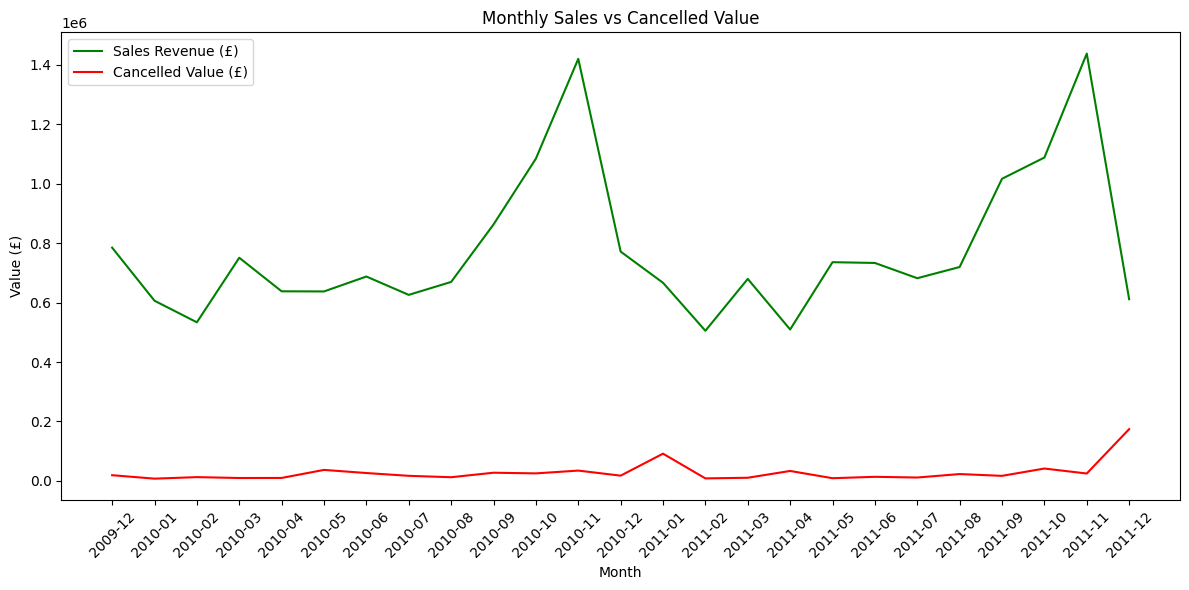

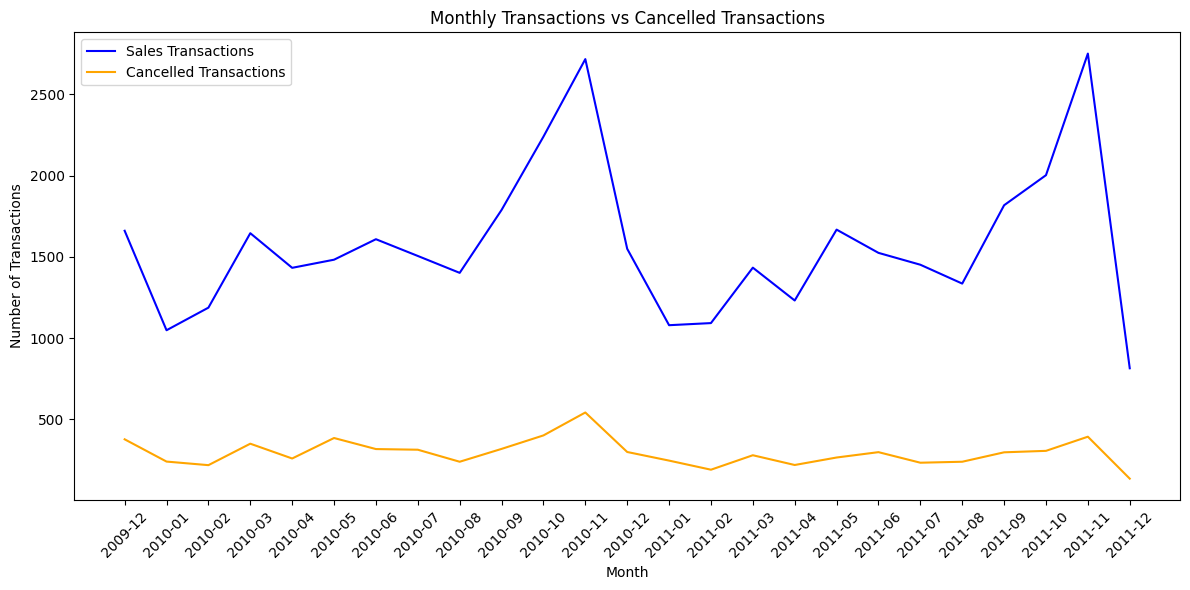

In [29]:
# Make sure InvoiceDate is datetime
valid_sales['InvoiceDate'] = pd.to_datetime(valid_sales['InvoiceDate'])
cancelled['InvoiceDate'] = pd.to_datetime(cancelled['InvoiceDate'])

# Add Year-Month column
valid_sales['YearMonth'] = valid_sales['InvoiceDate'].dt.to_period('M')
cancelled['YearMonth'] = cancelled['InvoiceDate'].dt.to_period('M')

# Aggregate sales
monthly_sales = valid_sales.groupby('YearMonth').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique'
}).rename(columns={'Revenue': 'SalesRevenue', 'Invoice': 'SalesTransactions'})

# Aggregate cancellations
monthly_cancel = cancelled.groupby('YearMonth').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique'
}).rename(columns={'Revenue': 'CancelledValue', 'Invoice': 'CancelledTransactions'})

# Merge
monthly_summary = monthly_sales.join(monthly_cancel, how='outer').fillna(0)
monthly_summary['CancelledValueAbs'] = monthly_summary['CancelledValue'].abs()

# Plot revenue vs cancelled value
plt.figure(figsize=(12,6))
plt.plot(monthly_summary.index.astype(str), monthly_summary['SalesRevenue'], label='Sales Revenue (£)', color='green')
plt.plot(monthly_summary.index.astype(str), monthly_summary['CancelledValueAbs'], label='Cancelled Value (£)', color='red')
plt.xticks(rotation=45)
plt.title('Monthly Sales vs Cancelled Value')
plt.xlabel('Month')
plt.ylabel('Value (£)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot transactions vs cancelled transactions
plt.figure(figsize=(12,6))
plt.plot(monthly_summary.index.astype(str), monthly_summary['SalesTransactions'], label='Sales Transactions', color='blue')
plt.plot(monthly_summary.index.astype(str), monthly_summary['CancelledTransactions'], label='Cancelled Transactions', color='orange')
plt.xticks(rotation=45)
plt.title('Monthly Transactions vs Cancelled Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()


From the time trend analysis, we can see:  
- Sales revenue and transactions clearly peak in **November and December**, showing strong seasonality.  
- Cancelled value and cancelled transactions also rise during these months, but this seems to be a result of the higher sales volume rather than an unusual spike in cancellations.  
- For most of the year, cancellations stay relatively steady and remain much lower compared to sales.  

In short, cancellations follow overall sales trends. This means time alone may not be a strong driver of cancellations, they increase mainly because there are simply more transactions during peak periods.  


# Final Insights & Recommendations  

From the analyses:  
- **Countries**: The UK shows the highest cancellations in value, but this is expected given its large sales volume. More worrying are **Germany** (282 cancelled orders) and **EIRE** (146), where cancellations are high compared to their smaller sales.  
- **Products**: A few products cause most of the losses. **PAPER CRAFT, LITTLE BIRDIE** (£168K cancelled in one order) and **CERAMIC STORAGE JAR** (£77K) stand out in value. Others like **CAKESTAND 3 TIER** (341 cancellations) and **CHERRY LIGHTS** (119) are cancelled often, showing repeated issues.  
- **Customers**: Some customers cancel nearly everything they order (e.g., IDs **16446**, **12346**), while others cancel frequently across many orders (e.g., **14911** with 93).  
- **Time**: Cancellations rise in November–December, but this follows sales seasonality, more sales naturally lead to more cancellations.  

### Recommendations  
1. **Focus on key markets**: Watch **Germany and EIRE**, where cancellations are high despite smaller sales.  
2. **Fix problem products**: Review items with high cancellations (e.g., **PAPER CRAFT, CERAMIC JAR, CAKESTAND**) for quality, descriptions, or packaging issues.  
3. **Address customer patterns**: Track customers with repeated or extreme cancellations and apply controls or tailored support.  
4. **Prepare for peak months**: Strengthen communication and logistics in **Nov–Dec** to keep cancellations lower during busy sales.  

In short, cancellations are not spread evenly. They are concentrated in **specific countries, products, and customers**. By focusing on these areas, the business can cut losses without needing broad changes across all operations.  
